# RetailMart Smart ETL Pipeline

### Building an Automated Retail Data Processing and Analytics Solution

---

### Submitted By

**Kashish Sharma**
Master of Computer Applications (MCA)

### Assignment

**Technical Project Assignment – Data Engineering**


# Project Overview

RetailMart Pvt. Ltd. operates multiple retail stores across India and generates large volumes of daily transactional sales data. Since the collected data is stored across multiple CSV files and contains real-world quality issues such as missing values, duplicate records, and inconsistent formats, an automated data engineering solution is required.

This project develops an end-to-end **ETL (Extract, Transform, Load) Pipeline** to process raw retail datasets into a structured, analysis-ready format. The pipeline performs ingestion, validation, cleaning, transformation, SQL loading, and reporting to support business intelligence and decision-making.

The final solution enables:

* Identification of top-selling products across cities
* Revenue analysis at store and city level
* Detection of missing and inconsistent records
* Generation of business insights through SQL and visualization

---

# Problem Statement

Design and implement a scalable data pipeline that reads retail sales data from multiple CSV sources, applies data cleaning and transformation techniques, loads the processed data into SQLite, and produces analytical reports for business users.

---

# Project Objectives

The project is designed to achieve the following objectives:

* Build an automated ETL workflow for retail datasets
* Improve data quality through cleaning and validation
* Integrate multiple datasets into a single analytical layer
* Generate meaningful business insights using SQL and Python
* Visualize revenue and sales trends for easier interpretation
* Implement reusable and maintainable pipeline execution

---

# Project Workflow

### Extract

Read and validate data from:

* sales_data.csv
* products.csv
* stores.csv

↓

### Transform

Perform:

* Missing value handling
* Duplicate removal
* Data type correction
* Dataset merging
* Revenue calculations

↓

### Load

Store processed data into:

* SQLite Database (`retail_sales`)

↓

### Report & Analyze

Generate:

* SQL Reports
* Revenue Insights
* Product Performance Analysis
* Visualizations

---

# Technology Stack

| Technology       | Purpose                   | Reason for Selection                       |
| ---------------- | ------------------------- | ------------------------------------------ |
| Python           | Pipeline Development      | Flexible and widely used for ETL workflows |
| Pandas           | Data Processing           | Efficient data cleaning and transformation |
| NumPy            | Numerical Analysis        | Fast analytical calculations               |
| SQLite           | Database Storage          | Lightweight relational database            |
| Matplotlib       | Visualization             | Clear analytical reporting                 |
| Jupyter Notebook | Documentation & Execution | Combines code, outputs, and explanation    |

---

# Expected Outcome

At the completion of this project, the pipeline produces a clean and centralized retail dataset capable of supporting reporting, SQL analytics, and business decision-making while demonstrating practical Data Engineering concepts.


# Data Ingestion

In [28]:
import pandas as pd
import numpy as np
import sqlite3

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [29]:
sales = pd.read_csv("sales_data.csv")
products = pd.read_csv("products.csv")
stores = pd.read_csv("stores.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [30]:
print("Sales Data")
sales.head()

Sales Data


,sale_id,store_id,product_id,quantity,sale_date,amount
0,1,S101,P101,2.0,2025-06-01,100000.0
1,2,S102,P102,5.0,2025-06-01,2500.0
2,3,S103,P103,3.0,2025-06-02,2700.0
3,4,S104,P104,4.0,2025-06-02,2400.0
4,5,S105,P105,NaN,2025-06-03,5000.0


In [31]:
print("Products Data")
products.head()

Products Data


,product_id,product_name,category,price
0,P101,Laptop,Electronics,50000
1,P102,Mouse,Electronics,500
2,P103,Keyboard,Electronics,900
3,P104,Chair,Furniture,600
4,P105,Table,Furniture,1000


In [32]:
print("Stores Data")
stores.head()

Stores Data


,store_id,store_name,city,region
0,S101,RetailMart Delhi,Delhi,North
1,S102,RetailMart Mumbai,Mumbai,West
2,S103,RetailMart Kolkata,Kolkata,East
3,S104,RetailMart Chennai,Chennai,South
4,S105,RetailMart Bengaluru,Bengaluru,South


In [33]:
print("Sales Shape :", sales.shape)
print("Products Shape :", products.shape)
print("Stores Shape :", stores.shape)

Sales Shape : (16, 6)
Products Shape : (15, 4)
Stores Shape : (15, 4)


__DATA TYPES__

In [34]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sale_id     16 non-null     int64  
 1   store_id    16 non-null     object 
 2   product_id  16 non-null     object 
 3   quantity    15 non-null     float64
 4   sale_date   16 non-null     object 
 5   amount      15 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 900.0+ bytes


In [35]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    15 non-null     object
 1   product_name  15 non-null     object
 2   category      15 non-null     object
 3   price         15 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 612.0+ bytes


In [36]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    15 non-null     object
 1   store_name  15 non-null     object
 2   city        15 non-null     object
 3   region      15 non-null     object
dtypes: object(4)
memory usage: 612.0+ bytes


__MISSING VALUES__

In [37]:
print("Sales Missing Values")
print(sales.isnull().sum())

Sales Missing Values
sale_id       0
store_id      0
product_id    0
quantity      1
sale_date     0
amount        1
dtype: int64


In [38]:
print("Products Missing Values")
print(products.isnull().sum())

Products Missing Values
product_id      0
product_name    0
category        0
price           0
dtype: int64


In [39]:
print("Stores Missing Values")
print(stores.isnull().sum())

Stores Missing Values
store_id      0
store_name    0
city          0
region        0
dtype: int64


__Standardize Column Names__

In [40]:
# Convert all column names to lowercase
sales.columns = sales.columns.str.lower().str.strip()
products.columns = products.columns.str.lower().str.strip()
stores.columns = stores.columns.str.lower().str.strip()

print("Column names standardized successfully!")

Column names standardized successfully!


In [41]:
print(sales.columns)
print(products.columns)
print(stores.columns)

Index(['sale_id', 'store_id', 'product_id', 'quantity', 'sale_date', 'amount'], dtype='object')
Index(['product_id', 'product_name', 'category', 'price'], dtype='object')
Index(['store_id', 'store_name', 'city', 'region'], dtype='object')


__DATA QUALITY REPORT__

In [42]:
print("="*50)
print("DATA QUALITY REPORT")
print("="*50)

print(f"Total Sales Records : {len(sales)}")
print(f"Duplicate Rows : {sales.duplicated().sum()}")
print(f"Missing Quantity : {sales['quantity'].isnull().sum()}")
print(f"Missing Amount : {sales['amount'].isnull().sum()}")

DATA QUALITY REPORT
Total Sales Records : 16
Duplicate Rows : 1
Missing Quantity : 1
Missing Amount : 1


# 2.Data Cleaning

#### Task 2: Data Cleaning
#### Cleaning Missing Values, Duplicates and Data Types

__Check Duplicate Records__

In [43]:
duplicate_count = sales.duplicated().sum()

print(f"Total Duplicate Rows Found: {duplicate_count}")

Total Duplicate Rows Found: 1


__Remove Duplicate Records__

In [44]:
Sduplicate_count = sales.duplicated().sum()

sales = sales.drop_duplicates().copy()

print("Duplicate rows removed successfully!")

Duplicate rows removed successfully!


__Check Missing Values Before Cleaning__

In [45]:
print(sales.isnull().sum())

sale_id       0
store_id      0
product_id    0
quantity      1
sale_date     0
amount        1
dtype: int64


__Fill Missing Quantity with 0__

In [46]:
sales["quantity"] = sales["quantity"].fillna(0)

print("Missing quantity filled successfully!")

Missing quantity filled successfully!


In [47]:
sales = sales.dropna(subset=["amount"]).copy()

print("Rows with missing amount removed!")

Rows with missing amount removed!


In [48]:
sales["sale_date"] = pd.to_datetime(sales["sale_date"])
sales["amount"] = sales["amount"].astype(float)

# Data Transformation

#### Merge Data and Generate Business Insights

__Merge Sales + Products__

In [49]:
sales_products = pd.merge(
    sales,
    products,
    on="product_id",
    how="inner"
)

print("Sales and Products merged successfully!")
sales_products.head()

Sales and Products merged successfully!


,sale_id,store_id,product_id,quantity,sale_date,amount,product_name,category,price
0,1,S101,P101,2.0,2025-06-01,100000.0,Laptop,Electronics,50000
1,2,S102,P102,5.0,2025-06-01,2500.0,Mouse,Electronics,500
2,3,S103,P103,3.0,2025-06-02,2700.0,Keyboard,Electronics,900
3,4,S104,P104,4.0,2025-06-02,2400.0,Chair,Furniture,600
4,5,S105,P105,0.0,2025-06-03,5000.0,Table,Furniture,1000


__Merge with Stores__

###### Merge Sales, Products and Stores Data

In [50]:
final_df = pd.merge(
    sales_products,
    stores,
    on="store_id",
    how="inner"
)

print("All datasets merged successfully!")
final_df.head()

All datasets merged successfully!


,sale_id,store_id,product_id,quantity,sale_date,amount,product_name,category,price,store_name,city,region
0,1,S101,P101,2.0,2025-06-01,100000.0,Laptop,Electronics,50000,RetailMart Delhi,Delhi,North
1,2,S102,P102,5.0,2025-06-01,2500.0,Mouse,Electronics,500,RetailMart Mumbai,Mumbai,West
2,3,S103,P103,3.0,2025-06-02,2700.0,Keyboard,Electronics,900,RetailMart Kolkata,Kolkata,East
3,4,S104,P104,4.0,2025-06-02,2400.0,Chair,Furniture,600,RetailMart Chennai,Chennai,South
4,5,S105,P105,0.0,2025-06-03,5000.0,Table,Furniture,1000,RetailMart Bengaluru,Bengaluru,South


__Check Final Shape__

In [51]:
print("Final Dataset Shape :", final_df.shape)

Final Dataset Shape : (14, 12)


__Calculate Total Revenue__

In [52]:
final_df["total_revenue"] = final_df["quantity"] * final_df["price"]

print("Total Revenue Column Added Successfully!")

Total Revenue Column Added Successfully!


__Display Dataset__

In [53]:
final_df.head()

,sale_id,store_id,product_id,quantity,sale_date,amount,product_name,category,price,store_name,city,region,total_revenue
0,1,S101,P101,2.0,2025-06-01,100000.0,Laptop,Electronics,50000,RetailMart Delhi,Delhi,North,100000.0
1,2,S102,P102,5.0,2025-06-01,2500.0,Mouse,Electronics,500,RetailMart Mumbai,Mumbai,West,2500.0
2,3,S103,P103,3.0,2025-06-02,2700.0,Keyboard,Electronics,900,RetailMart Kolkata,Kolkata,East,2700.0
3,4,S104,P104,4.0,2025-06-02,2400.0,Chair,Furniture,600,RetailMart Chennai,Chennai,South,2400.0
4,5,S105,P105,0.0,2025-06-03,5000.0,Table,Furniture,1000,RetailMart Bengaluru,Bengaluru,South,0.0


__Revenue Statistics__

##### Revenue Statistics using NumPy

In [54]:
print("Mean Revenue :", np.mean(final_df["total_revenue"]))
print("Maximum Revenue :", np.max(final_df["total_revenue"]))
print("Minimum Revenue :", np.min(final_df["total_revenue"]))

Mean Revenue : 15864.285714285714
Maximum Revenue : 100000.0
Minimum Revenue : 0.0


__Revenue by City__

In [55]:
city_revenue = final_df.groupby("city")["total_revenue"].sum().sort_values(ascending=False)

city_revenue

city
Delhi         100000.0
Guwahati       50000.0
Kochi          18000.0
Jaipur         15000.0
Lucknow         9600.0
Chandigarh      8800.0
Pune            8500.0
Ahmedabad       3000.0
Kolkata         2700.0
Mumbai          2500.0
Chennai         2400.0
Bhopal          1200.0
Patna            400.0
Bengaluru          0.0
Name: total_revenue, dtype: float64

### City-wise Revenue Visualization

In [56]:
import matplotlib.pyplot as plt

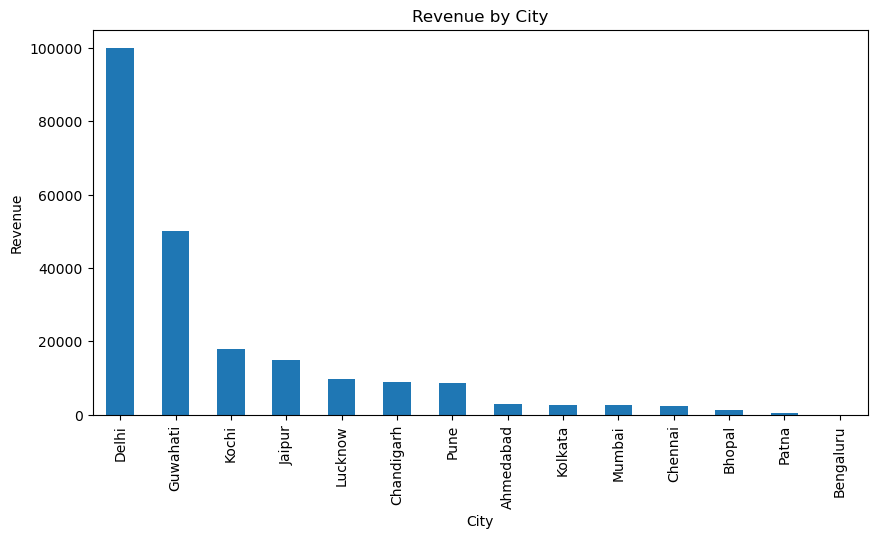

In [66]:
city=(
final_df.groupby("city")
["total_revenue"]
.sum()
.sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
city.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

## Data Loading into SQLite Database

##### Store the Cleaned Data into SQLite Database

__SQLite Database Create__

In [67]:
import sqlite3

# Create or connect to SQLite database
conn = sqlite3.connect("RetailMart.db")

__Load Data into Database__

In [68]:
final_df.to_sql(
    "retail_sales",
    conn,
    if_exists="replace",
    index=False
)

print("Data loaded into SQLite database successfully!")

Data loaded into SQLite database successfully!


__Verify the Data Stored in Database__

In [69]:
query = "SELECT * FROM retail_sales LIMIT 5"

pd.read_sql(query, conn)

,sale_id,store_id,product_id,quantity,sale_date,amount,product_name,category,price,store_name,city,region,total_revenue
0,1,S101,P101,2.0,2025-06-01 00:00:00,100000.0,Laptop,Electronics,50000,RetailMart Delhi,Delhi,North,100000.0
1,2,S102,P102,5.0,2025-06-01 00:00:00,2500.0,Mouse,Electronics,500,RetailMart Mumbai,Mumbai,West,2500.0
2,3,S103,P103,3.0,2025-06-02 00:00:00,2700.0,Keyboard,Electronics,900,RetailMart Kolkata,Kolkata,East,2700.0
3,4,S104,P104,4.0,2025-06-02 00:00:00,2400.0,Chair,Furniture,600,RetailMart Chennai,Chennai,South,2400.0
4,5,S105,P105,0.0,2025-06-03 00:00:00,5000.0,Table,Furniture,1000,RetailMart Bengaluru,Bengaluru,South,0.0


__SQL Query - Top 3 Best Selling Products__

In [70]:
query = """
SELECT
    product_name,
    SUM(quantity) AS total_quantity
FROM retail_sales
GROUP BY product_name
ORDER BY total_quantity DESC
LIMIT 3;
"""

top_products = pd.read_sql(query, conn)

top_products

,product_name,total_quantity
0,Pen,20.0
1,Notebook,15.0
2,Water Bottle,10.0


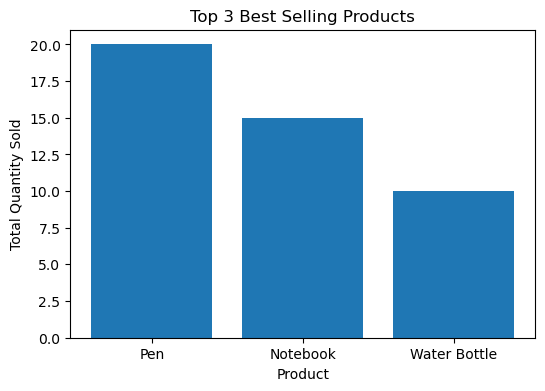

In [71]:
plt.figure(figsize=(6,4))

plt.bar(top_products["product_name"], top_products["total_quantity"])

plt.title("Top 3 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.show()

__SQL Query - Revenue Per Store Per Day__

In [72]:
query = """
SELECT
    store_name,
    sale_date,
    SUM(total_revenue) AS total_revenue
FROM retail_sales
GROUP BY store_name, sale_date
ORDER BY sale_date;
"""

store_revenue = pd.read_sql(query, conn)

store_revenue

,store_name,sale_date,total_revenue
0,RetailMart Delhi,2025-06-01 00:00:00,100000.0
1,RetailMart Mumbai,2025-06-01 00:00:00,2500.0
2,RetailMart Chennai,2025-06-02 00:00:00,2400.0
3,RetailMart Kolkata,2025-06-02 00:00:00,2700.0
4,RetailMart Bengaluru,2025-06-03 00:00:00,0.0
5,RetailMart Jaipur,2025-06-04 00:00:00,15000.0
6,RetailMart Pune,2025-06-04 00:00:00,8500.0
7,RetailMart Ahmedabad,2025-06-05 00:00:00,3000.0
8,RetailMart Lucknow,2025-06-05 00:00:00,9600.0
9,RetailMart Bhopal,2025-06-06 00:00:00,1200.0


# Reporting and Business Insights

##### Summary Report

In [73]:
print("="*50)
print("RETAIL SALES SUMMARY REPORT")
print("="*50)

print("Total Transactions :", len(final_df))

print("Total Revenue :", final_df["total_revenue"].sum())

print("Top Selling City :", city_revenue.idxmax())

top_product = (
    final_df.groupby("product_name")["quantity"]
    .sum()
    .idxmax()
)

print("Top Selling Product :", top_product)

RETAIL SALES SUMMARY REPORT
Total Transactions : 14
Total Revenue : 222100.0
Top Selling City : Delhi
Top Selling Product : Pen


# Pipeline Automation and Error Handling

In [74]:
def run_pipeline():
    try:
        # Step 1: Load Data
        sales = pd.read_csv(r"T:\RetailMart_Project\DATA\sales_data.csv")
        products = pd.read_csv(r"T:\RetailMart_Project\DATA\products.csv")
        stores = pd.read_csv(r"T:\RetailMart_Project\DATA\stores.csv")

        # Step 2: Standardize Column Names
        sales.columns = sales.columns.str.lower().str.strip()
        products.columns = products.columns.str.lower().str.strip()
        stores.columns = stores.columns.str.lower().str.strip()

        # Step 3: Remove Duplicates
        sales = sales.drop_duplicates()

        # Step 4: Fill Missing Values
        sales["quantity"] = sales["quantity"].fillna(0)

        # Step 5: Remove Rows with Missing Amount
        sales = sales.dropna(subset=["amount"]).copy()

        # Step 6: Convert Data Types
        sales["sale_date"] = pd.to_datetime(sales["sale_date"])
        sales["amount"] = sales["amount"].astype(float)

        # Step 7: Merge DataFrames
        sales_products = pd.merge(sales, products, on="product_id", how="inner")
        final_df = pd.merge(sales_products, stores, on="store_id", how="inner")

        # Step 8: Create Total Revenue Column
        final_df["total_revenue"] = final_df["quantity"] * final_df["price"]

        # Step 9: Load into SQLite Database
        conn = sqlite3.connect("RetailMart.db")

        final_df.to_sql(
            "retail_sales",
            conn,
            if_exists="replace",
            index=False
        )

        conn.close()

        print("ETL Pipeline Executed Successfully!")
        return final_df

    except FileNotFoundError as e:
        print("Error: One or more CSV files were not found.")
        print(e)

    except Exception as e:
        print("An unexpected error occurred:")
        print(e)

In [75]:
run_pipeline()

ETL Pipeline Executed Successfully!


,sale_id,store_id,product_id,quantity,sale_date,amount,product_name,category,price,unnamed: 4,unnamed: 5,store_name,city,region,total_revenue
0,1,101,P101,2.0,2026-01-06,1000.0,Laptop,Electronics,50000,NaN,NaN,RetailMart Delhi,Delhi,North,100000.0
1,2,102,P102,1.0,2026-01-06,500.0,Mouse,Electronics,500,NaN,NaN,RetailMart Jaipur,Jaipur,North,500.0
2,3,101,P103,0.0,2026-02-06,900.0,Keyboard,Electronics,900,NaN,NaN,RetailMart Delhi,Delhi,North,0.0
3,5,104,P104,2.0,2026-03-06,1200.0,Chair,Furniture,600,NaN,NaN,RetailMart Pune,Pune,West,1200.0
4,6,101,P102,1.0,2026-03-06,500.0,Mouse,Electronics,500,NaN,NaN,RetailMart Delhi,Delhi,North,500.0
5,7,102,P103,2.0,2026-03-06,1800.0,Keyboard,Electronics,900,NaN,NaN,RetailMart Jaipur,Jaipur,North,1800.0
6,8,103,P105,4.0,2026-04-06,4000.0,Table,Furniture,1000,NaN,NaN,RetailMart Mumbai,Mumbai,West,4000.0
7,9,104,P101,0.0,2026-04-06,1000.0,Laptop,Electronics,50000,NaN,NaN,RetailMart Pune,Pune,West,0.0
8,10,101,P104,3.0,2026-05-06,1800.0,Chair,Furniture,600,NaN,NaN,RetailMart Delhi,Delhi,North,1800.0
9,11,102,P105,2.0,2026-05-06,2000.0,Table,Furniture,1000,NaN,NaN,RetailMart Jaipur,Jaipur,North,2000.0


# Conclusion

__This project successfully implemented a complete ETL (Extract, Transform, Load) pipeline using Python, Pandas, NumPy, SQLite, and SQL.__

__The pipeline loads raw sales data, cleans missing values and duplicate records, transforms the data by merging multiple datasets, calculates total revenue, stores the processed data into a SQLite database, and generates business insights through SQL queries and visualizations.__

__This project demonstrates practical data engineering concepts used in real-world retail analytics.__